In [ ]:
# notebook to perform updated COSMIC analysis with inclusion of indels for revision
# 011226

In [1]:
# import packages
import pandas as pd
import numpy as np
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter
pd.options.mode.chained_assignment = None

In [2]:
# define function to calculate odds ratios
# does not account for activity - filter for activity if desired
# not set up for multiple variates, pre-filter DF for that
# eg filter full DF for only 250bp promoters and then use recurrence to compare recurrent v unique promoter variants
def oddsR_calculator(df, column_of_interest, emvar_col):
    pos = df[column_of_interest] == 1
    
    a = df.loc[pos, emvar_col].sum()       # positive + emvar
    b = pos.sum() - a                       # positive + non-emvar
    c = df.loc[~pos, emvar_col].sum()      # negative + emvar
    d = (~pos).sum() - c                    # negative + non-emvar

    table = np.array([[a, b], [c, d]])

    oddsr, pval = stats.fisher_exact(table)
    ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)

    odds_df = pd.DataFrame([{
        'label': column_of_interest,
        'OddsR': oddsr,
        'p_val': pval,
        'round_p': np.round(pval, 4),
        'lowerCI': ci[0],
        'upperCI': ci[1],
        'n_pos_emvar': a,
        'n_pos_nonemVar': b,
        'n_neg_emvar': c,
        'n_neg_nonemVar': d,
    }])

    return odds_df, table

In [3]:
def oddsR_feature_by_skew_bin_all(preds_df, list_of_bins, feature, feature_ann):
    df = preds_df.copy()
    df['mean_skew_bin'] = pd.cut(df['mean_skew'], list_of_bins)

    # Precompute totals once
    total_with_feature = df[feature].sum()
    total_without_feature = len(df) - total_with_feature

    results = []

    for bin_label, bin_df in df.groupby('mean_skew_bin', observed=True):
        a = bin_df[feature].sum()           # in bin, has feature
        b = len(bin_df) - a                  # in bin, no feature
        c = total_with_feature - a           # not in bin, has feature
        d = total_without_feature - b        # not in bin, no feature

        table = np.array([[a, b], [c, d]])

        oddsr, pval = stats.fisher_exact(table)
        ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)

        results.append({
            'Feature': feature_ann,
            'OddsR': oddsr,
            'p_val': pval,
            'round_p': np.round(pval, 4),
            'lowerCI': ci[0],
            'upperCI': ci[1],
            'Bin': bin_label,
            'n_bin': len(bin_df),
            'n_feature_in_bin': a,
        })

    return pd.DataFrame(results).sort_values('Bin').reset_index(drop=True)

In [4]:
def oddsR_emvar_by_act_bin_max(preds_df, skew_threshold=0.5):
    df = preds_df.copy()

    # Classify emvar once on the full df
    df['is_emvar'] = (df['max_skew'].abs() > skew_threshold).astype(int)

    # Split once
    recurrent = df[df['recurrent'] == 1]
    unique = df[df['recurrent'] != 1]

    # Precompute totals
    total_recurrent = len(recurrent)
    total_unique = len(unique)

    results = []

    for bin_label in df['max_act_bin'].dropna().unique():
        bin_r = recurrent[recurrent['max_act_bin'] == bin_label]
        bin_u = unique[unique['max_act_bin'] == bin_label]

        a = bin_r['is_emvar'].sum()          # recurrent emvars in bin
        c = total_recurrent - a              # recurrent non-emvars (all other bins)
        b = bin_u['is_emvar'].sum()          # unique emvars in bin
        d = total_unique - b                 # unique non-emvars (all other bins)

        table = np.array([[a, b], [c, d]])

        oddsr, pval = stats.fisher_exact(table)
        ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)

        results.append({
            'feature': 'emVar',
            'oddsR': oddsr,
            'p_val': pval,
            'lowerCI': ci[0],
            'upperCI': ci[1],
            'Bin': bin_label,
            'label': str(bin_label),
            'n_recurrent_emvars': a,
            'n_unique_emvars': b,
            'n_recurrent_in_bin': len(bin_r),
            'n_unique_in_bin': len(bin_u),
        })

    return pd.DataFrame(results).sort_values('Bin').reset_index(drop=True)

In [5]:
# define function to assign max skew and activity bin
def reformat_df4act_bin (df):
    # get cell type of max skew
    max_skew_cell = []
    max_skew_l2fc = []
    for k_skew, h_skew, s_skew in zip(df['k562_skew_pred'],
                                      df['hepg2_skew_pred'],
                                      df['sknsh_skew_pred']):
        skew_list = [k_skew, h_skew, s_skew]
        max_skew = max([k_skew, h_skew, s_skew], key=abs)
        if skew_list[0] == max_skew:
            max_skew_cell.append('k562')
            max_skew_l2fc.append(max_skew)
        elif skew_list[1] == max_skew:
            max_skew_cell.append('hepg2')
            max_skew_l2fc.append(max_skew)
        elif skew_list[2] == max_skew:
            max_skew_cell.append('sknsh')
            max_skew_l2fc.append(max_skew)
    df['max_skew_cell'] = max_skew_cell
    # get matching activity bin
    k_act_bin = df['k562_act_bin'].tolist()
    h_act_bin = df['hepg2_act_bin'].tolist()
    s_act_bin = df['sknsh_act_bin'].tolist()
    act_bin = []
    for i,j in tqdm(zip(range(len(df)),
                   df['max_skew_cell'])):
        if j == 'k562':
            act_bin.append(k_act_bin[i])
        elif j == 'hepg2':
            act_bin.append(h_act_bin[i])
        elif j == 'sknsh':
            act_bin.append(s_act_bin[i])
    df['max_act_bin'] = act_bin
    # return skew of max cell type
    df['max_skew'] = max_skew_l2fc
    return df

In [6]:
# open annotated COSMIC predictions
cosmic_preds = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.031826.tsv', sep = '\t', low_memory=False)
# add activity bins
# annotate activity ranges
cosmic_preds['mean_ref_bin'] = pd.cut(cosmic_preds['mean_ref_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['k562_act_bin'] = pd.cut(cosmic_preds['k562_max_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['hepg2_act_bin'] = pd.cut(cosmic_preds['hepg2_max_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])
cosmic_preds['sknsh_act_bin'] = pd.cut(cosmic_preds['sknsh_max_act'], [float('-inf'), 1, 2, 3, 4, 5, float('inf')])

In [7]:
# filter for only non-coding + synonymous variants
cosmic_preds = cosmic_preds[(cosmic_preds['vep_coding_related'] == 0) | (cosmic_preds['vep_most_severe'] == 'synonymous_variant')]

In [8]:
len(cosmic_preds)

2190594

In [9]:
# count number of recurrent emvars
# in promoters. no exon filter
n_recurrent_pro_emvars = len(cosmic_preds[(cosmic_preds['emvar_any'] == 1) &
                                          (cosmic_preds['recurrent'] == 1) &
                                          (cosmic_preds['250bp_pro'] == 1)])
print(f'The number of recurrent promoter emVars is {n_recurrent_pro_emvars}')
# out of promoters, no exon filter
n_recurrent_emvars_noPro = len(cosmic_preds[(cosmic_preds['emvar_any'] == 1) &
                                            (cosmic_preds['recurrent'] == 1) &
                                            (cosmic_preds['250bp_pro'] == 0)])
print(f'The number of recurrent non-promoter emVars is {n_recurrent_emvars_noPro}')

The number of recurrent promoter emVars is 113
The number of recurrent non-promoter emVars is 1279


In [10]:
# calculate odds ratios for generating plot from figure 2D
# odds ratio a variant is an emVar in the selected bin vs. non-emVar
# recurrent vs. unique variant
recurrent_OR_df, recurrent_2x2 = oddsR_calculator(cosmic_preds,
                                                  'recurrent',
                                                  'emvar_any')
# 250bp promoter vs. non-promoter
twoFifty_OR_df, twoFifty_2x2 = oddsR_calculator(cosmic_preds,
                                                '250bp_pro',
                                                'emvar_any')
# cnc promoter
cnc_OR_df, cnc_2x2 = oddsR_calculator(cosmic_preds,
                                      'cnc_pro',
                                      'emvar_any')
# recurrent 250bp promoter
recurrent250_OR_df, recurrent250_2x2 = oddsR_calculator(cosmic_preds,
                                                        'recurrent_250bp_pro',
                                                        'emvar_any')
# recurrent cnc promoter
recurrentCNC_OR_df, recurrentCNC_2x2 = oddsR_calculator(cosmic_preds,
                                                        'recurrent_cnc_pro',
                                                        'emvar_any')
# concatenate all together for plotting
cat_odds_or = pd.concat([recurrent_OR_df,
                         twoFifty_OR_df,
                         cnc_OR_df,
                         recurrent250_OR_df,
                         recurrentCNC_OR_df])
# add a column to concatenated df with label for y axis on plot below
cat_odds_or['plot_labs'] = ['Recurrent',
                            '250bp Promoter',
                            'CNC Promoter',
                            'Recurrent Promoter',
                            'Recurrent CNC Promoter']
# define a color palette for recurrence, etc.
feature_palette = {'recurrent' : '#1F271B',
                   'Recurrent' : '#1F271B',
                   '250bp_promoter' : "#F15B60",
                   '250bp Promoter' : "#F15B60",
                   '250_pro_seqlet' : 'dodgerblue',
                   '250bp Promoter Seqlet' : 'dodgerblue',
                   'cnc_database_250bp_promoter' : "#00A14B",
                   'CNC Promoter' : "#00A14B",
                   'recurrent_250bp_promoter' : "#F26522",
                   'Recurrent Promoter' : "#F26522",
                   'recurrent_cnc_promoter' : "#6A4D94",
                   'Recurrent CNC Promoter' : "#6A4D94"}

In [11]:
cat_odds_or

,label,OddsR,p_val,round_p,lowerCI,upperCI,n_pos_emvar,n_pos_nonemVar,n_neg_emvar,n_neg_nonemVar,plot_labs
0,recurrent,1.336959,6.513069e-24,0.0,1.265646,1.411360,1392,52915,41223,2095064,Recurrent
0,250bp_pro,6.612525,1.263515e-293,0.0,6.091263,7.169385,677,5231,41938,2142748,250bp Promoter
0,cnc_pro,10.203924,5.136338e-34,0.0,7.492114,13.679005,55,272,42560,2147707,CNC Promoter
0,recurrent_250bp_pro,15.773110,2.256201e-85,0.0,12.652003,19.538588,113,362,42502,2147617,Recurrent Promoter
0,recurrent_cnc_pro,17.917507,7.224303e-23,0.0,11.098993,28.129890,27,76,42588,2147903,Recurrent CNC Promoter


In [12]:
cat_odds_or.filter(['n_pos_emvar', 'n_pos_nonemVar', 'n_neg_emvar', 'n_neg_nonemVar']).sum(axis=1)

0    2190594
0    2190594
0    2190594
0    2190594
0    2190594
dtype: int64

In [13]:
# plot TERT promoter mutations
# -124 COSV57196518
# -146 COSV57196531
# filter full cosmic predictions for TERT promoter mutations
minus124_skew = cosmic_preds[cosmic_preds['id'] == 'COSV57196518']['mean_skew'].tolist()[0]
minus146_skew = cosmic_preds[cosmic_preds['id'] == 'COSV57196531']['mean_skew'].tolist()[0]
# build the DF for plotting
tert_pro_vars2plot = pd.DataFrame({
    'Skew' : [minus124_skew, minus146_skew],
    'TERT Promoter Mutation' : ['-124 C>T', '-146 C>T']
})

/tmp/ipykernel_280547/3382716143.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


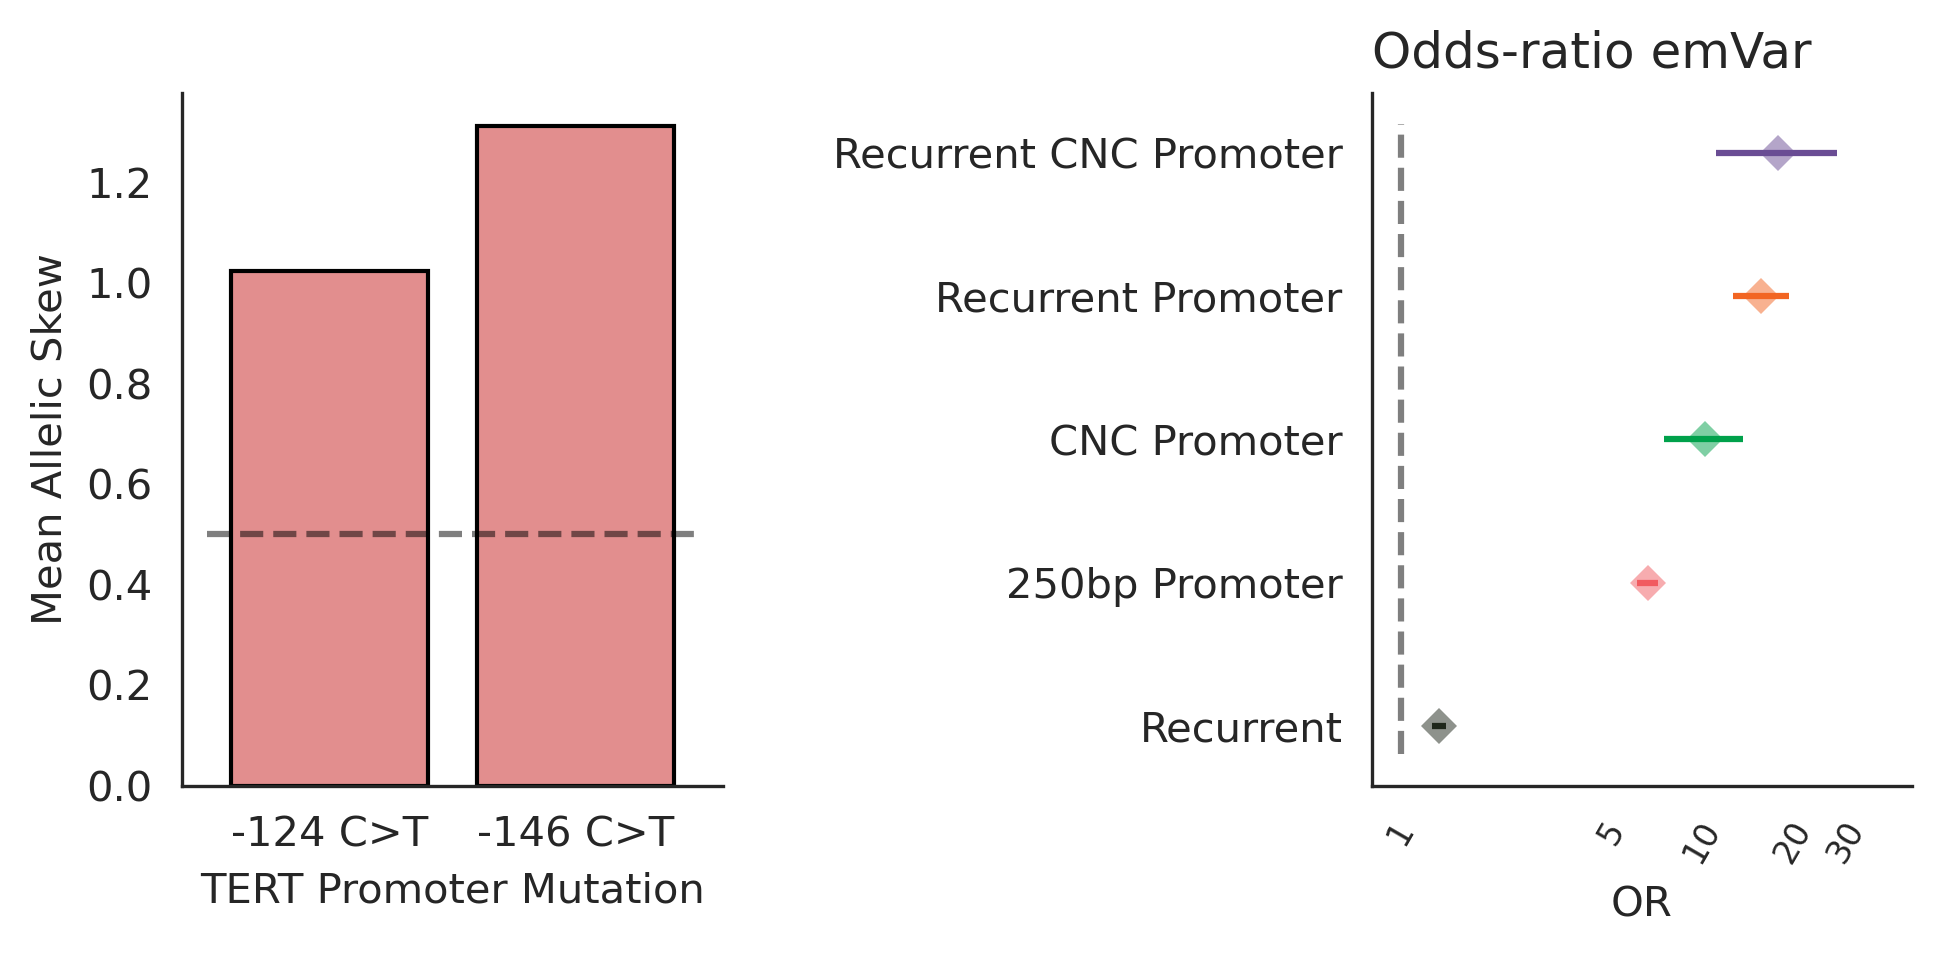

In [14]:
f = plt.figure(figsize=(10, 3), dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1,4)
# add tert promoter skew
with sns.axes_style("white"):
    ax_01 = f.add_subplot(gs[0,0])
    sns.barplot(data=tert_pro_vars2plot,
            x='TERT Promoter Mutation',
            y='Skew',
            color='lightcoral',
            edgecolor='k')
    xmin, xmax = ax_01.get_xlim()
    plt.hlines(y=.5, xmin=xmin, xmax=xmax, color='k', alpha=.5, linestyle='dashed')
    plt.ylabel('Mean Allelic Skew')
# add overall enrichments
with sns.axes_style("white"):
    ax_03 = f.add_subplot(gs[0, 2:3])
    ax_03.set_xscale('log')
    sns.pointplot(
        data=cat_odds_or.sort_values(by='OddsR', ascending = False), x="OddsR", y="plot_labs",
        palette=feature_palette, linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    plt.ylabel('')
    for lower, upper, lab in zip(cat_odds_or['lowerCI'],
                                 cat_odds_or['upperCI'],
                                 cat_odds_or['plot_labs']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color=feature_palette.get(lab))
    ymin, ymax = ax_03.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.title('Odds-ratio emVar', loc='left')
    plt.xlabel('OR')
    plt.xticks([1,5,10,20, 30], ['1','5','10', '20', '30'], rotation=60, size=8)
    plt.xlim(.8, 50)
sns.despine()
plt.subplots_adjust(wspace=.1, hspace=.3)
#plt.savefig('../figures/tert_promoter_muts_and_emvar_enrichments_rev1.pdf')

In [15]:
# calculate oddsR by mean skew bin for each promoter feature
# recurrent
recurrent_oddsR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds,
                                                       [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                       'recurrent',
                                                       'Recurrent')
recurrent_oddsR_by_bin['label'] = [str(i) for i in recurrent_oddsR_by_bin['Bin']]
# recurrent non-promoter
recurrent_oddsR_by_bin_no_pro = oddsR_feature_by_skew_bin_all(cosmic_preds[cosmic_preds['250bp_pro'] == 0],
                                                              [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                              'recurrent',
                                                              'Recurrent: Non-Promoter')
recurrent_oddsR_by_bin_no_pro['label'] = [str(i) for i in recurrent_oddsR_by_bin_no_pro['Bin']]
# recurrent in DHS
recurrent_oddsR_by_bin_no_pro_in_dhs = oddsR_feature_by_skew_bin_all(cosmic_preds[(cosmic_preds['250bp_pro'] == 0) &
                                                                                  (cosmic_preds['dhs'] == 1)],
                                                                     [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                                     'recurrent',
                                                                     'Recurrent: In DHS')
recurrent_oddsR_by_bin_no_pro_in_dhs['label'] = [str(i) for i in recurrent_oddsR_by_bin_no_pro_in_dhs['Bin']]
# 250bp promoter
twoFifty_oddsR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds,
                                                      [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                      '250bp_pro',
                                                      '250bp_pro')
twoFifty_oddsR_by_bin['label'] = [str(i) for i in twoFifty_oddsR_by_bin['Bin']]
# # CNC promoter
cnc_pro_oddsR_by_bin =  oddsR_feature_by_skew_bin_all(cosmic_preds,
                                                      [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                      'cnc_pro',
                                                      'CNC Promoter')
cnc_pro_oddsR_by_bin['label'] = [str(i) for i in cnc_pro_oddsR_by_bin['Bin']]
# # Promoter Recurrent
recurrent_promoter_OR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds,
                                                             [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                             'recurrent_250bp_pro',
                                                             'Recurrent Promoter')
recurrent_promoter_OR_by_bin['label'] = [str(i) for i in recurrent_promoter_OR_by_bin['Bin']]
# # CNC Recurrent
recurrent_cnc_promoter_OR_by_bin = oddsR_feature_by_skew_bin_all(cosmic_preds,
                                                                 [float('-inf'), -1, -.5, -.2, -.05, .05, .2, .5, 1, float('inf')],
                                                                 'recurrent_cnc_pro',
                                                                 'Recurrent CNC Promoter')
recurrent_cnc_promoter_OR_by_bin['label'] = [str(i) for i in recurrent_cnc_promoter_OR_by_bin['Bin']]

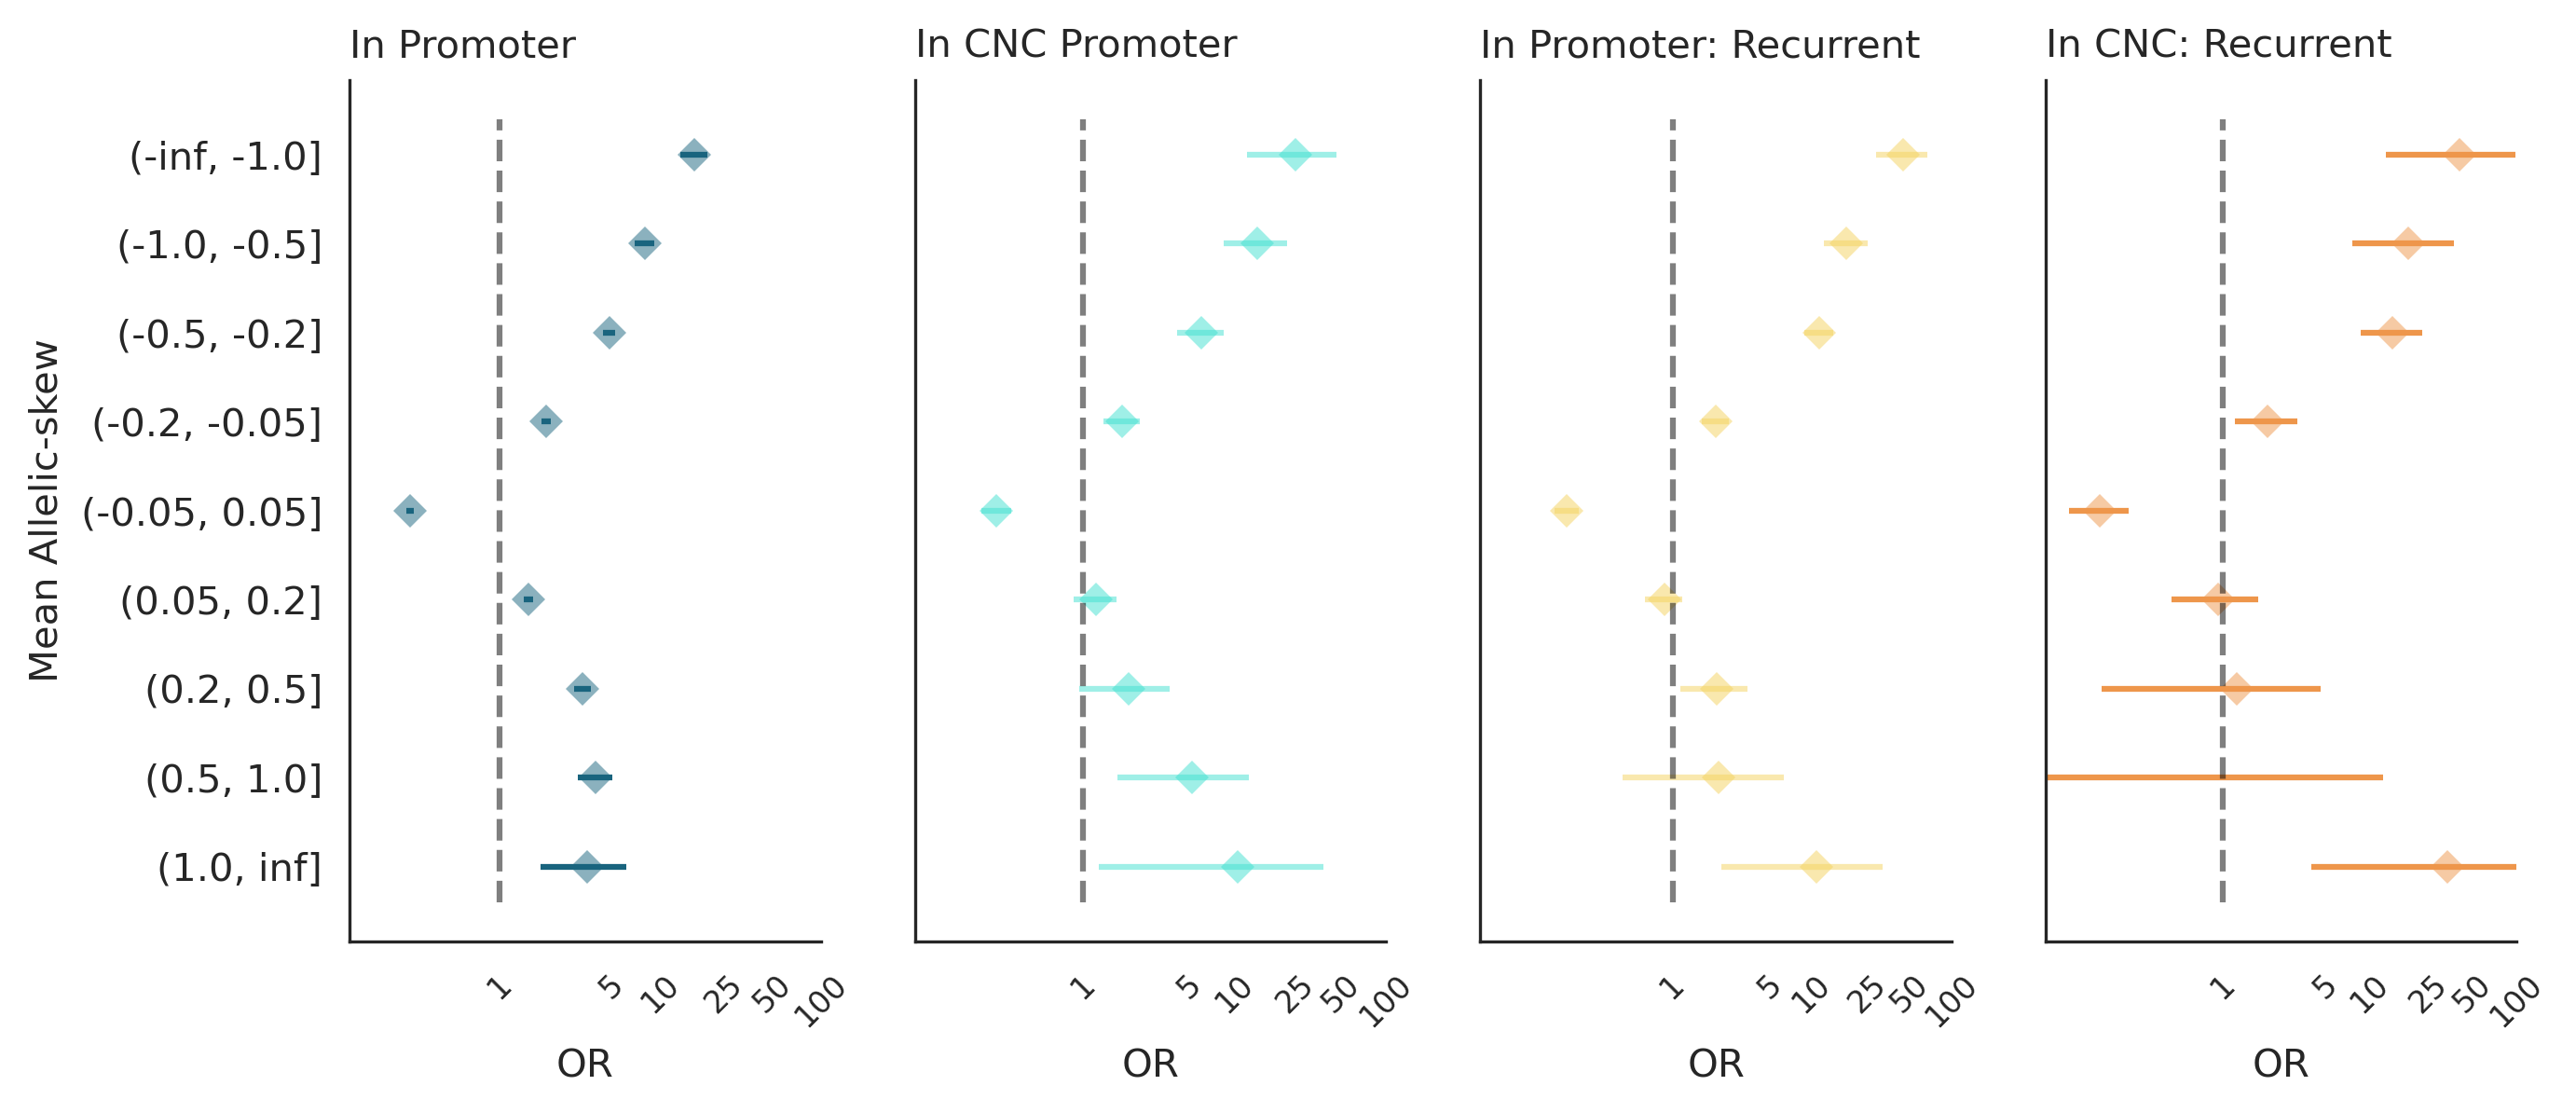

In [16]:
# plot middle row of figure 2
# promoter by skew bin all categories
f = plt.figure(figsize=(10, 4), dpi=300)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1, 4)
# promoter alone
with sns.axes_style("white"):
    ax1 = f.add_subplot(gs[0,0])
    ax1.set_xscale('log')
    sns.pointplot(
    data=twoFifty_oddsR_by_bin, x="OddsR", y="label",
    color="#19647E", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    for lower, upper, lab in zip(twoFifty_oddsR_by_bin['lowerCI'],
                                 twoFifty_oddsR_by_bin['upperCI'],
                                 twoFifty_oddsR_by_bin['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='#19647E')
    ymin, ymax = ax1.get_ylim()
    plt.ylabel('Mean Allelic-skew')
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    plt.title('In Promoter', loc='left', size=10)
    plt.xlabel('OR')
# cnc promoter
with sns.axes_style("white"):
    ax2 = f.add_subplot(gs[0,1])
    ax2.set_xscale('log')
    sns.pointplot(
    data=cnc_pro_oddsR_by_bin, x="OddsR", y="label",
    color="turquoise", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax2.yaxis.set_visible(False)
    for lower, upper, lab in zip(cnc_pro_oddsR_by_bin['lowerCI'],
                                 cnc_pro_oddsR_by_bin['upperCI'],
                                 cnc_pro_oddsR_by_bin['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='turquoise', alpha=.5)
    ymin, ymax = ax2.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    plt.title('In CNC Promoter', loc='left', size=10)
    plt.xlabel('OR')
# plot recurrent promoter
with sns.axes_style("white"):
    ax3 = f.add_subplot(gs[0,2])
    ax3.set_xscale('log')
    sns.pointplot(
    data=recurrent_promoter_OR_by_bin, x="OddsR", y="label",
    color="#F4D35E", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax3.yaxis.set_visible(False)
    for lower, upper, lab in zip(recurrent_promoter_OR_by_bin['lowerCI'],
                                 recurrent_promoter_OR_by_bin['upperCI'],
                                 recurrent_promoter_OR_by_bin['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='#F4D35E', alpha=.5)
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    plt.title('In Promoter: Recurrent', loc='left', size=10)
    plt.xlabel('OR')
# plot recurrent cnc promoter
with sns.axes_style("white"):
    ax4 = f.add_subplot(gs[0,3])
    ax4.set_xscale('log')
    sns.pointplot(
    data=recurrent_cnc_promoter_OR_by_bin, x="OddsR", y="label",
    color="#EE964B", linestyle="none", marker="D", markersize=6, alpha=.5, linewidth=0
)
    ax4.yaxis.set_visible(False)
    for lower, upper, lab in zip(recurrent_cnc_promoter_OR_by_bin['lowerCI'],
                        recurrent_cnc_promoter_OR_by_bin['upperCI'],
                           recurrent_cnc_promoter_OR_by_bin['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='#EE964B')
    ymin, ymax = ax4.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    plt.xticks([1, 5, 10, 25, 50, 100], ['1','5','10', '25', '50', '100'], rotation=45, size=8)
    plt.title('In CNC: Recurrent', loc='left', size=10)
    plt.xlabel('OR')
sns.despine()
#plt.savefig('../figures/promoter_skew_bin_row_all_rev1.pdf', bbox_inches='tight')

In [17]:
# calculate the emVar rate by activity bin
cosmic_preds4act_bin = reformat_df4act_bin(cosmic_preds)
# calculate oddsR an emVar is recurrent by activity bin
recurrent_emvar_or_by_act = oddsR_emvar_by_act_bin_max(cosmic_preds4act_bin)
# calculate oddsR an emVar is recurrent by activity bin - no promoters
recurrent_emvar_or_by_act_no_pro = oddsR_emvar_by_act_bin_max(cosmic_preds4act_bin[cosmic_preds4act_bin['250bp_pro'] == 0])
# calculate oddsR an emVar is recurrent by activity bin - no promoters, in DHS
recurrent_emvar_or_by_act_no_pro_in_dhs = oddsR_emvar_by_act_bin_max(cosmic_preds4act_bin[(cosmic_preds4act_bin['250bp_pro'] == 0) &
                                                                                          (cosmic_preds4act_bin['dhs'] == 1)])
# calculate oddsR an emVar is recurrent by activity bin - in promoter
recurrent_emvar_or_by_act_250_pro = oddsR_emvar_by_act_bin_max(cosmic_preds4act_bin[cosmic_preds4act_bin['250bp_pro'] == 1])

2190594it [00:00, 3496600.52it/s]


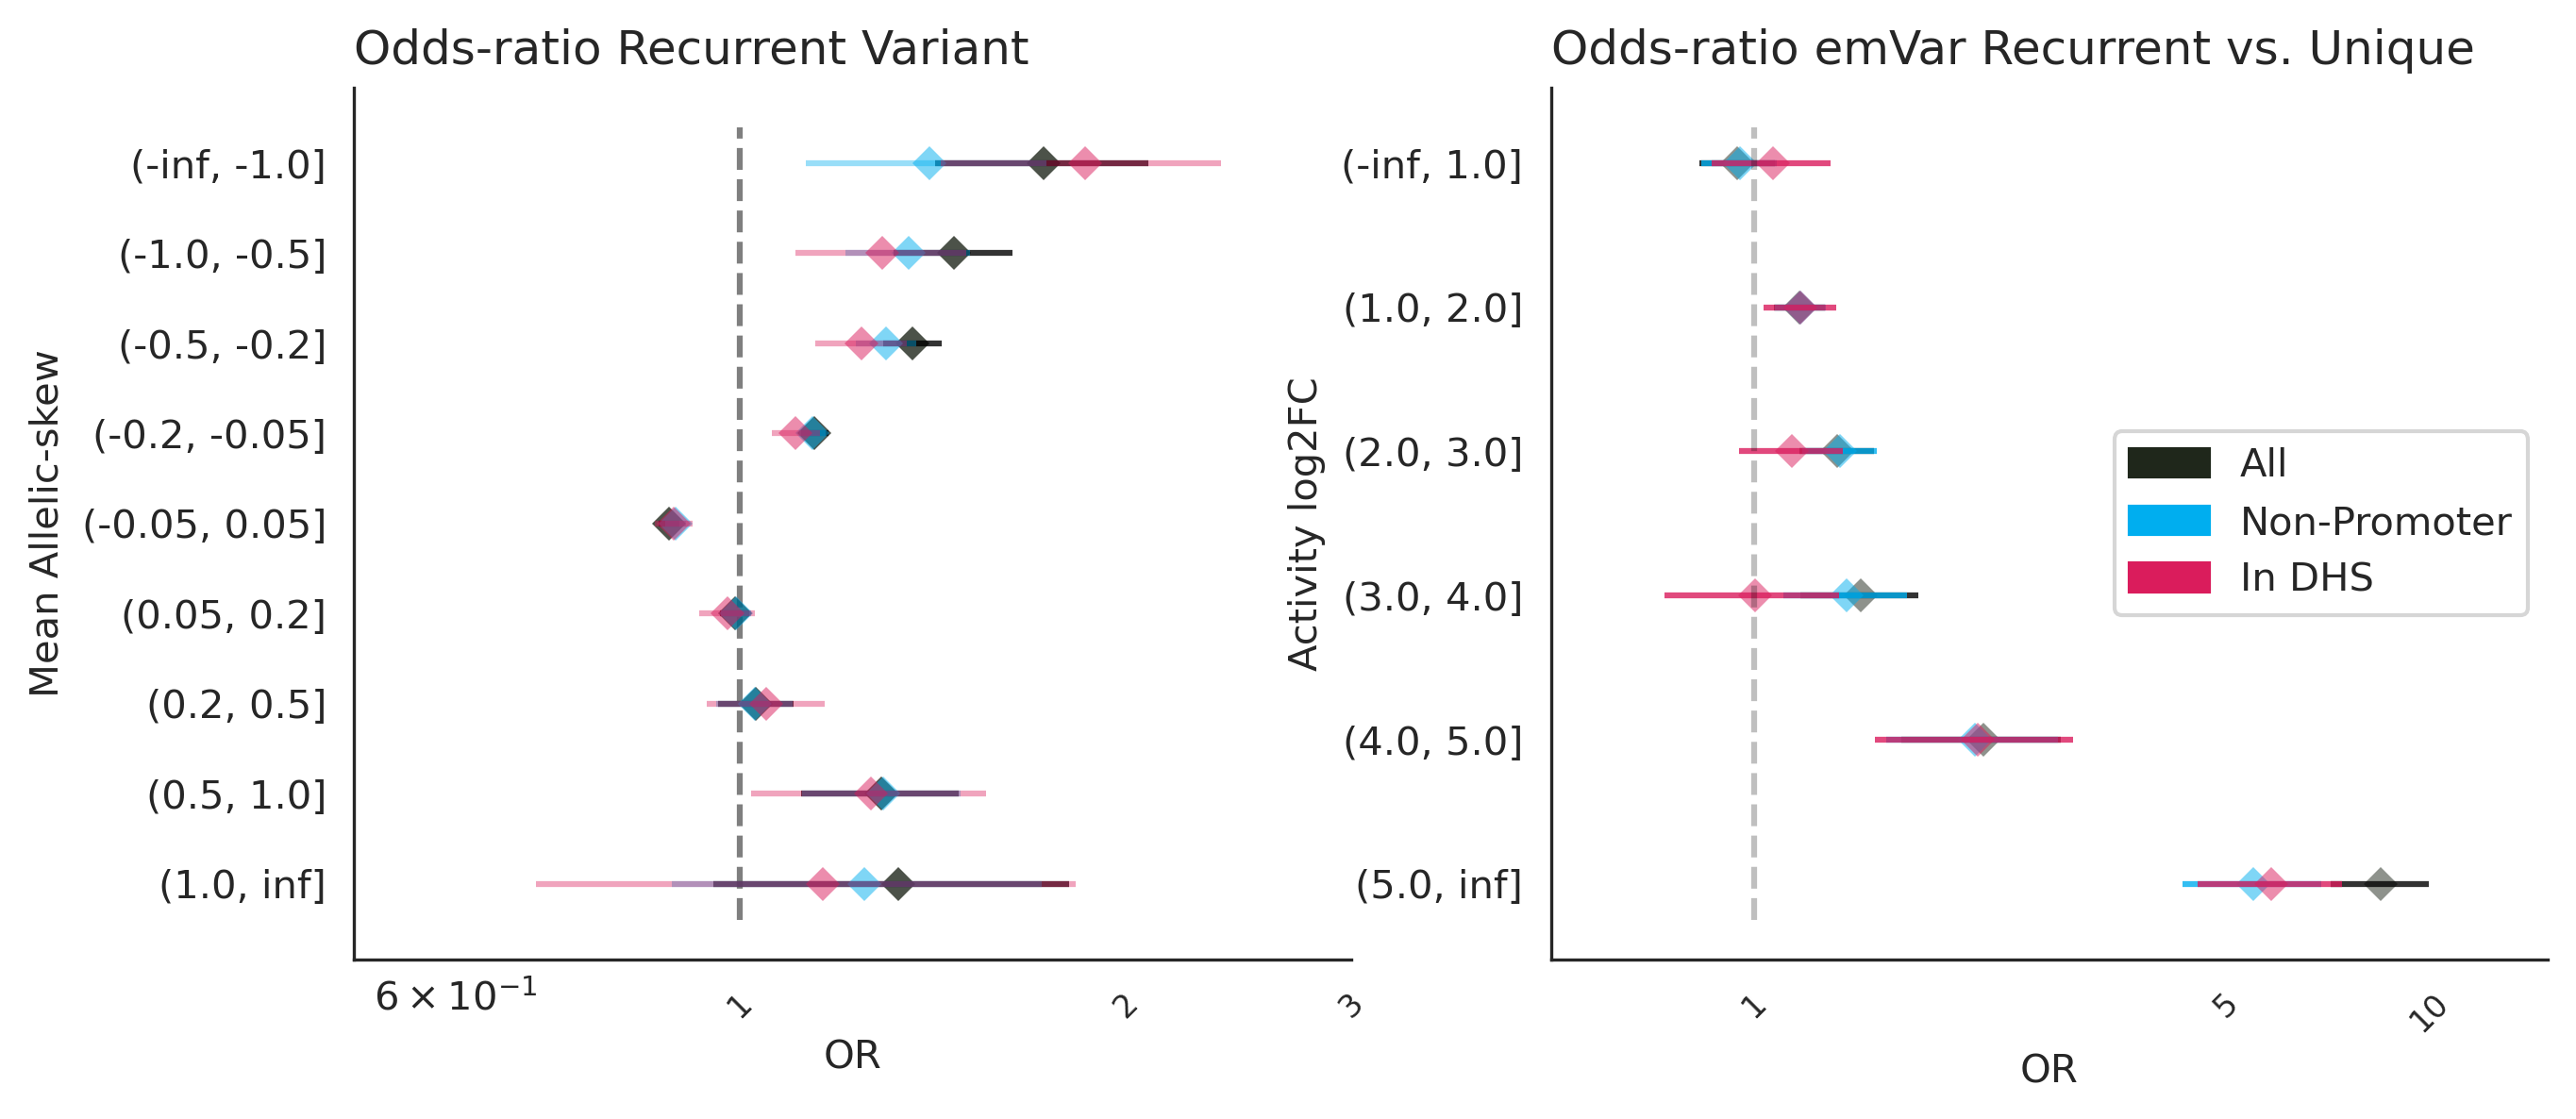

In [18]:
black_patch = mpatches.Patch(color="#1F271B", label='All')
green_patch = mpatches.Patch(color="#00AEEF", label='Non-Promoter')
blue_patch = mpatches.Patch(color="#DA1C5C", label='In DHS')
# max ref | alt by cell type - binned by prediction with maximum skew
f = plt.figure(dpi=300,figsize=(10,4))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
gs = f.add_gridspec(1, 2)
# mean allelic skew bins
with sns.axes_style("white"):
    ax0 = f.add_subplot(gs[0, 0])
    ax0.set_xscale('log')
    # plot all
    sns.pointplot(
    data=recurrent_oddsR_by_bin, x="OddsR", y="label",
    color="#1F271B", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.8
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin['lowerCI'],
                                 recurrent_oddsR_by_bin['upperCI'],
                                 recurrent_oddsR_by_bin['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='k', alpha=.8)
    ymin, ymax = ax0.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.5, linestyle='dashed')
    # plot non-promoter
    sns.pointplot(
    data=recurrent_oddsR_by_bin_no_pro, x="OddsR", y="label",
    color="#00AEEF", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin_no_pro['lowerCI'],
                                 recurrent_oddsR_by_bin_no_pro['upperCI'],
                                 recurrent_oddsR_by_bin_no_pro['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='#00AEEF', alpha=.4)
    # plot in dhs
    sns.pointplot(
    data=recurrent_oddsR_by_bin_no_pro_in_dhs, x="OddsR", y="label",
    color="#DA1C5C", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5,
)
    for lower, upper, lab in zip(recurrent_oddsR_by_bin_no_pro_in_dhs['lowerCI'],
                                 recurrent_oddsR_by_bin_no_pro_in_dhs['upperCI'],
                                 recurrent_oddsR_by_bin_no_pro_in_dhs['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='#DA1C5C', alpha=.4)
    plt.title('Odds-ratio Recurrent Variant', loc='left')
    plt.ylabel('Mean Allelic-skew')
    plt.xlim(.5, 3)
    plt.xticks([1, 2, 3], ['1','2','3'], rotation=45, size=8)
    plt.xlabel('OR')
# recurrent by activity bin
with sns.axes_style("white"):
    ax1 = f.add_subplot(gs[0, 1])
    ax1.set_xscale('log')
    # all
    sns.pointplot(data=recurrent_emvar_or_by_act, x="oddsR", y="Bin",
    color="#1F271B", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act['lowerCI'],
                                 recurrent_emvar_or_by_act['upperCI'],
                                 recurrent_emvar_or_by_act['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color='k', alpha=.8)
    # non-promoter
    sns.pointplot(data=recurrent_emvar_or_by_act_no_pro, x="oddsR", y="Bin",
    color="#00AEEF", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act_no_pro['lowerCI'],
                                 recurrent_emvar_or_by_act_no_pro['upperCI'],
                                 recurrent_emvar_or_by_act_no_pro['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color="#00AEEF", alpha=.8)
    ymin, ymax = ax1.get_ylim()
    # in dhs
    sns.pointplot(data=recurrent_emvar_or_by_act_no_pro_in_dhs, x="oddsR", y="Bin",
    color="#DA1C5C", linestyle="none", marker="D", markersize=6, linewidth=0, alpha=.5)
    for lower, upper, lab in zip(recurrent_emvar_or_by_act_no_pro_in_dhs['lowerCI'],
                                 recurrent_emvar_or_by_act_no_pro_in_dhs['upperCI'],
                                 recurrent_emvar_or_by_act_no_pro_in_dhs['label']):
        plt.hlines(xmin=lower, xmax=upper, y=lab, color="#DA1C5C", alpha=.8)
    
    ymin, ymax = ax1.get_ylim()
    plt.vlines(x=1, ymin=ymin, ymax=ymax, color='k', alpha=.25, linestyle='dashed')
    plt.title('Odds-ratio emVar Recurrent vs. Unique', loc='left')
    plt.xlabel('OR')
    plt.xlim(.8,15)
    plt.xticks([0.5, 1, 5, 10], ['', '1','5','10'], rotation=45, size=8)
    plt.ylabel('Activity log2FC')
    plt.legend(handles=[black_patch,
                        green_patch,
                        blue_patch], loc='center right')
sns.despine()
#plt.savefig('../figures/or_by_skew_bin_and_act_bin_rev1.pdf')

In [20]:
cosmic_preds.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,primary_histology,all_histology,vep_most_severe,vep_coding_related,mean_ref_bin,k562_act_bin,hepg2_act_bin,sknsh_act_bin,max_skew_cell,max_act_bin
0,chr5,12057,COSV104949790,C,G,0.290299,0.484281,0.193983,0.236332,0.486731,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",hepg2,"(-inf, 1.0]"
1,chr5,12314,COSV106176984,C,T,3.124992,2.110848,-1.014144,2.444942,1.962961,...,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma,0,0,"(2.0, 3.0]","(3.0, 4.0]","(2.0, 3.0]","(2.0, 3.0]",k562,"(3.0, 4.0]"
2,chr5,13609,COSV64422606,C,T,0.165250,0.171957,0.006708,0.221217,0.226838,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",sknsh,"(-inf, 1.0]"
3,chr5,14173,COSV61294243,A,C,-0.059066,-0.023485,0.035582,-0.192251,-0.133702,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",hepg2,"(-inf, 1.0]"
4,chr5,14196,COSV106241292,G,C,-0.066014,-0.059922,0.006092,-0.220630,-0.198749,...,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",sknsh,"(-inf, 1.0]"


In [21]:
cosmic_preds.keys()

Index(['chrom', 'pos', 'id', 'ref', 'alt', 'k562_ref_pred', 'k562_alt_pred',
       'k562_skew_pred', 'hepg2_ref_pred', 'hepg2_alt_pred', 'hepg2_skew_pred',
       'sknsh_ref_pred', 'sknsh_alt_pred', 'sknsh_skew_pred', 'k562_max_act',
       'hepg2_max_act', 'sknsh_max_act', 'k562_active', 'hepg2_active',
       'sknsh_active', 'k562_emvar', 'hepg2_emvar', 'sknsh_emvar', 'emvar_any',
       'mean_ref_act', 'mean_skew', 'max_skew', 'var_id', 'recurrence',
       'recurrent', '250bp_pro', 'cnc_pro', 'dhs', 'recurrent_250bp_pro',
       'recurrent_cnc_pro', 'indel', 'k562_dELS_seqlet', 'hepg2_dELS_seqlet',
       'sknsh_dELS_seqlet', 'dELS_seqlet', 'encode_dELS', 'recurrent_dELS',
       'k562_pro_seqlet', 'hepg2_pro_seqlet', 'sknsh_pro_seqlet',
       '250_pro_seqlet', 'k562_dELS_seqlet_tf_fam', 'hepg2_dELS_seqlet_tf_fam',
       'sknsh_dELS_seqlet_tf_fam', 'k562_dELS_seqlet_enh_ID',
       'hepg2_dELS_seqlet_enh_ID', 'sknsh_dELS_seqlet_enh_ID',
       'primary_histology', 'all_histology

In [43]:
recurrent_emvar_or_by_act

,feature,oddsR,p_val,lowerCI,upperCI,Bin,label,n_recurrent_emvars,n_unique_emvars,n_recurrent_in_bin,n_unique_in_bin
0,emVar,0.945446,3.989644e-01,0.830397,1.072219,"(-inf, 1.0]","(-inf, 1.0]",250,10399,46926,1924047
1,emVar,1.168540,4.703935e-04,1.070781,1.273005,"(1.0, 2.0]","(1.0, 2.0]",546,18407,5038,159216
2,emVar,1.328637,1.686882e-05,1.169303,1.504059,"(2.0, 3.0]","(2.0, 3.0]",260,7707,1191,33803
3,emVar,1.439841,5.603155e-04,1.172137,1.751677,"(3.0, 4.0]","(3.0, 4.0]",104,2843,412,11151
4,emVar,2.188753,1.272311e-07,1.654308,2.846359,"(4.0, 5.0]","(4.0, 5.0]",59,1061,246,4606
5,emVar,8.467138,1.591404e-90,7.141136,9.992624,"(5.0, inf]","(5.0, inf]",173,806,494,3464


In [25]:
cosmic_preds4act_bin.head()

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,primary_histology,all_histology,vep_most_severe,vep_coding_related,mean_ref_bin,k562_act_bin,hepg2_act_bin,sknsh_act_bin,max_skew_cell,max_act_bin
0,chr5,12057,COSV104949790,C,G,0.290299,0.484281,0.193983,0.236332,0.486731,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",hepg2,"(-inf, 1.0]"
1,chr5,12314,COSV106176984,C,T,3.124992,2.110848,-1.014144,2.444942,1.962961,...,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma,0,0,"(2.0, 3.0]","(3.0, 4.0]","(2.0, 3.0]","(2.0, 3.0]",k562,"(3.0, 4.0]"
2,chr5,13609,COSV64422606,C,T,0.165250,0.171957,0.006708,0.221217,0.226838,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",sknsh,"(-inf, 1.0]"
3,chr5,14173,COSV61294243,A,C,-0.059066,-0.023485,0.035582,-0.192251,-0.133702,...,carcinoma,carcinoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",hepg2,"(-inf, 1.0]"
4,chr5,14196,COSV106241292,G,C,-0.066014,-0.059922,0.006092,-0.220630,-0.198749,...,undifferentiated-unclassified_sarcoma,undifferentiated-unclassified_sarcoma,0,0,"(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]","(-inf, 1.0]",sknsh,"(-inf, 1.0]"


In [26]:
# calculate the percent overlap of emvars with activity > 5 and DHS
l2fcGreater5_emvars = cosmic_preds4act_bin[(cosmic_preds4act_bin['max_act_bin'].astype(str) == '(5.0, inf]') &
                                           (cosmic_preds4act_bin['emvar_any'] == 1)]
print(f'{l2fcGreater5_emvars['dhs'].sum() / len(l2fcGreater5_emvars):.2} of emvars with l2fc > 5 overlap DHS elements')

0.88 of emvars with l2fc > 5 overlap DHS elements


In [27]:
# calculate the enrichment for recurrence at all active bins (> 1)
active_bin = cosmic_preds4act_bin[cosmic_preds4act_bin['max_act_bin'].astype(str).isin(['(2.0, 3.0]', '(1.0, 2.0]', '(3.0, 4.0]', '(4.0, 5.0]', '(5.0, inf'])]
inactive_bin = cosmic_preds4act_bin[~cosmic_preds4act_bin['max_act_bin'].astype(str).isin(['(2.0, 3.0]', '(1.0, 2.0]', '(3.0, 4.0]', '(4.0, 5.0]', '(5.0, inf'])]
# calculate the n's of each
a = active_bin['recurrent'].sum() # active recurrent
b = len(active_bin) - a # active not recurrent
c = inactive_bin['recurrent'].sum() # inactive recurrent
d = len(inactive_bin) - c # inactive not recurrent
table = np.array([[a, b], [c, d]])

oddsr, pval = stats.fisher_exact(table)
ci = stats.contingency.odds_ratio(table).confidence_interval(0.95)
print(f'the odds ratio that an active variant is recurrent is {oddsr:.2}, p-value = {pval:.2e}')

the odds ratio that an active variant is recurrent is 1.3, p-value = 8.18e-104
